# Extracción de conocimiento en Bases de Datos
## Lab19 - Evaluación de Algoritmos

**Objetivo:** Evaluar distintos algoritmos de aprendizaje supervisado para determinar cuál ofrece el mejor desempeño antes de integrarlo a un sistema.

En este laboratorio se compararán los siguientes algoritmos:

- Árbol de Decisión.
- Random Forest.
- Support Vector Machine (SVM).
- Regresión Lineal utilizada como modelo de referencia para aproximar las clases.

In [1]:
# Cargar las librerías requeridas
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Carga del conjunto de datos

In [2]:
# Cargamos el dataset Wine directamente desde scikit-learn
wine = load_wine(as_frame=True)

In [3]:
# Mostramos la descripción general del dataset
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
# Convertimos el dataset en un DataFrame de pandas
dfWine = wine.frame

In [5]:
# Mostramos los primeros cinco registros
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploración del conjunto de datos

In [6]:
# Consultamos el número de filas y columnas
dfWine.shape

(178, 14)

In [7]:
# Consultamos los nombres de las columnas
dfWine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [8]:
# Mostramos los nombres originales de las clases
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [9]:
# Revisamos los tipos de datos y valores no nulos
dfWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [10]:
# Obtenemos estadísticas descriptivas de las variables numéricas
dfWine.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## Limpieza y preparación de los datos

In [11]:
# Verificamos si existen valores nulos por columna
dfWine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [12]:
# Verificamos si existen registros duplicados
print("Registros duplicados:", dfWine.duplicated().sum())

Registros duplicados: 0


In [13]:
# Renombramos la columna objetivo para identificarla fácilmente
dfWine.rename(columns={"target": "clase_vino"}, inplace=True)

In [14]:
# Mostramos la cantidad de registros que tiene cada clase
dfWine["clase_vino"].value_counts().sort_index()

clase_vino
0    59
1    71
2    48
Name: count, dtype: int64

In [15]:
# Guardamos los nombres de las clases para utilizarlos en las gráficas
nombres_clases = list(wine.target_names)

print("Clases del dataset:")
for numero, nombre in enumerate(nombres_clases):
    print(numero, "-", nombre)

Clases del dataset:
0 - class_0
1 - class_1
2 - class_2


## Identificar variables predictoras y variable objetivo

In [16]:
# Variables predictoras: todas las columnas excepto la clase del vino
X = dfWine.drop(columns=["clase_vino"])

In [17]:
# Variable objetivo: clase del vino
y = dfWine["clase_vino"]

In [18]:
print("Variables predictoras:")
print(X.columns)

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

Variable objetivo:
clase_vino


## Dividir los datos en entrenamiento y prueba

- **80 %** de los datos se utilizarán para entrenamiento.
- **20 %** de los datos se utilizarán para prueba.
- `stratify=y` conserva la proporción de las tres clases.
- `random_state=42` permite obtener los mismos resultados al volver a ejecutar el notebook.

In [19]:
# Dividimos el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
# Mostramos las dimensiones de cada conjunto
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 13)
X_test: (36, 13)
y_train: (142,)
y_test: (36,)


## Escalado de las variables

SVM y Regresión Lineal pueden verse afectados por las diferentes escalas de las variables. Por esta razón se estandarizan los datos para estos dos modelos.

Los algoritmos basados en árboles no necesitan escalado, por lo que Árbol de Decisión y Random Forest utilizarán los datos originales.

In [21]:
# Creamos el objeto para estandarizar las variables
scaler = StandardScaler()

In [22]:
# Ajustamos el escalador únicamente con los datos de entrenamiento
# Después transformamos los datos de entrenamiento y prueba
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

In [23]:
# Mostramos una comparación entre datos originales y datos escalados
print("Datos originales:")
display(X_train.head())

print("Datos escalados:")
display(pd.DataFrame(
    X_train_escalado,
    columns=X.columns,
    index=X_train.index
).head())

Datos originales:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0


Datos escalados:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,0.385801,-0.637871,1.776668,-1.224532,0.696430,0.526865,0.732292,-0.169549,-0.415783,-0.167467,0.624378,0.252908,0.467725
30,0.948519,-0.765445,1.253174,0.853284,0.091785,1.172795,1.333181,-0.590457,1.349742,0.305303,1.067155,0.151048,1.815768
26,0.523354,-0.519409,0.954034,-1.046433,-0.445678,0.930572,1.006382,-0.169549,-0.260002,-0.081509,-0.128343,0.893172,1.516203
12,0.973529,-0.555859,0.168793,-1.076116,-0.714409,0.526865,0.816627,-0.590457,0.363125,0.262324,0.890044,0.427526,1.932265
148,0.435820,0.820120,0.056615,0.556453,-0.512860,-0.555068,-1.291756,0.756449,-0.606183,1.474335,-1.766619,-1.435059,-0.297831


# 1. Árbol de Decisión

Un Árbol de Decisión divide los datos mediante preguntas sobre las características. Cada división busca separar las clases de la mejor manera posible.

In [24]:
# Creamos el modelo de Árbol de Decisión
arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [25]:
# Entrenamos el modelo y medimos su tiempo de entrenamiento
inicio = time.perf_counter()
arbol.fit(X_train, y_train)
tiempo_arbol = time.perf_counter() - inicio

In [26]:
# Realizamos predicciones con los datos de prueba
pred_arbol = arbol.predict(X_test)

In [27]:
# Calculamos la exactitud del Árbol de Decisión
accuracy_arbol = accuracy_score(y_test, pred_arbol)

print(f"Accuracy del Árbol de Decisión: {accuracy_arbol:.4f}")
print(f"Porcentaje de aciertos: {accuracy_arbol * 100:.2f}%")
print(f"Tiempo de entrenamiento: {tiempo_arbol:.6f} segundos")

Accuracy del Árbol de Decisión: 0.9444
Porcentaje de aciertos: 94.44%
Tiempo de entrenamiento: 0.006153 segundos


In [28]:
# Mostramos el reporte de clasificación del Árbol de Decisión
print(classification_report(
    y_test,
    pred_arbol,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



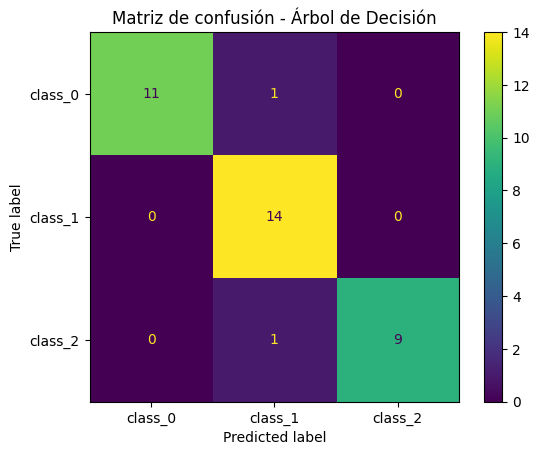

In [29]:
# Mostramos la matriz de confusión del Árbol de Decisión
cm_arbol = confusion_matrix(y_test, pred_arbol)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_arbol,
    display_labels=nombres_clases
)

disp.plot()
plt.title("Matriz de confusión - Árbol de Decisión")
plt.show()

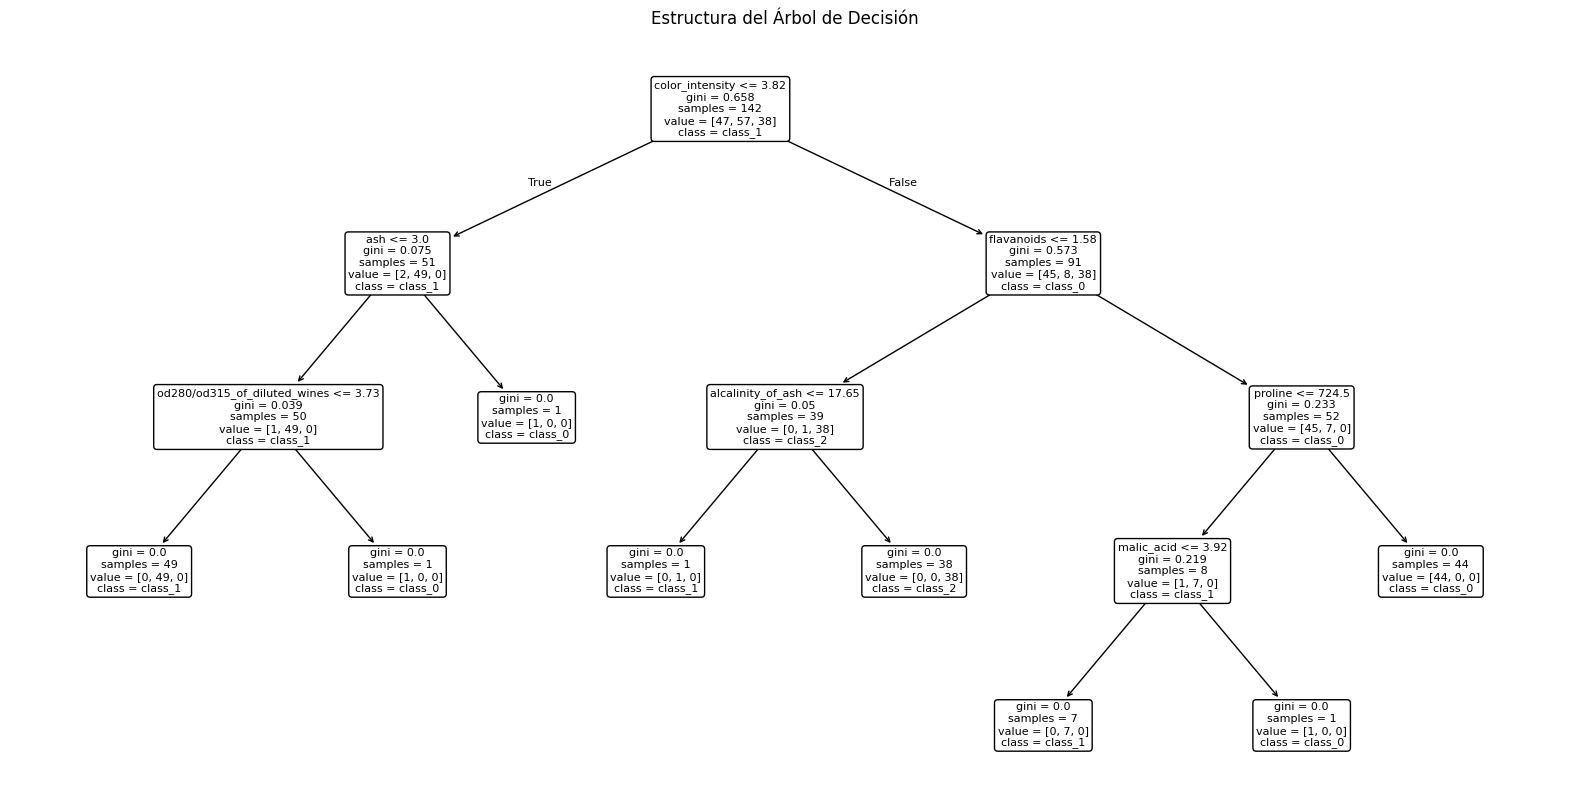

In [30]:
# Visualizamos la estructura del Árbol de Decisión
plt.figure(figsize=(20, 10))

plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=nombres_clases,
    rounded=True,
    fontsize=8
)

plt.title("Estructura del Árbol de Decisión")
plt.show()

# 2. Random Forest

Random Forest combina muchos árboles de decisión. Cada árbol realiza una predicción y el bosque selecciona la clase con mayor número de votos.

In [31]:
# Creamos el modelo Random Forest con 200 árboles
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [32]:
# Entrenamos el modelo y medimos su tiempo de entrenamiento
inicio = time.perf_counter()
random_forest.fit(X_train, y_train)
tiempo_random_forest = time.perf_counter() - inicio

In [33]:
# Realizamos predicciones con Random Forest
pred_random_forest = random_forest.predict(X_test)

In [34]:
# Calculamos la exactitud de Random Forest
accuracy_random_forest = accuracy_score(y_test, pred_random_forest)

print(f"Accuracy de Random Forest: {accuracy_random_forest:.4f}")
print(f"Porcentaje de aciertos: {accuracy_random_forest * 100:.2f}%")
print(f"Tiempo de entrenamiento: {tiempo_random_forest:.6f} segundos")

Accuracy de Random Forest: 1.0000
Porcentaje de aciertos: 100.00%
Tiempo de entrenamiento: 0.381821 segundos


In [35]:
# Mostramos el reporte de clasificación de Random Forest
print(classification_report(
    y_test,
    pred_random_forest,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



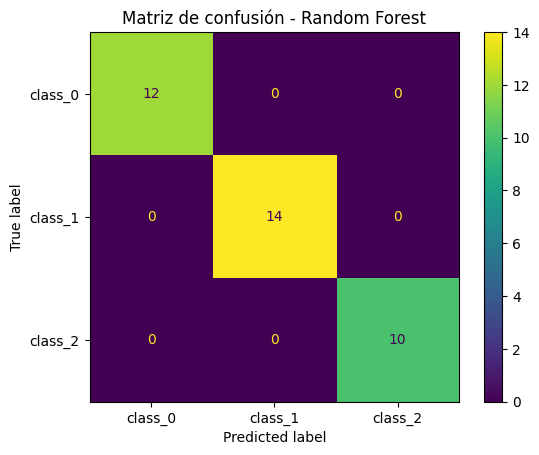

In [36]:
# Mostramos la matriz de confusión de Random Forest
cm_random_forest = confusion_matrix(y_test, pred_random_forest)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_random_forest,
    display_labels=nombres_clases
)

disp.plot()
plt.title("Matriz de confusión - Random Forest")
plt.show()

In [37]:
# Obtenemos la importancia de cada variable según Random Forest
importancias = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importancias

color_intensity                 0.187404
flavanoids                      0.168373
proline                         0.157024
alcohol                         0.108171
hue                             0.094966
od280/od315_of_diluted_wines    0.089898
total_phenols                   0.051274
magnesium                       0.035210
malic_acid                      0.030246
proanthocyanins                 0.028266
alcalinity_of_ash               0.026168
ash                             0.014577
nonflavanoid_phenols            0.008423
dtype: float64

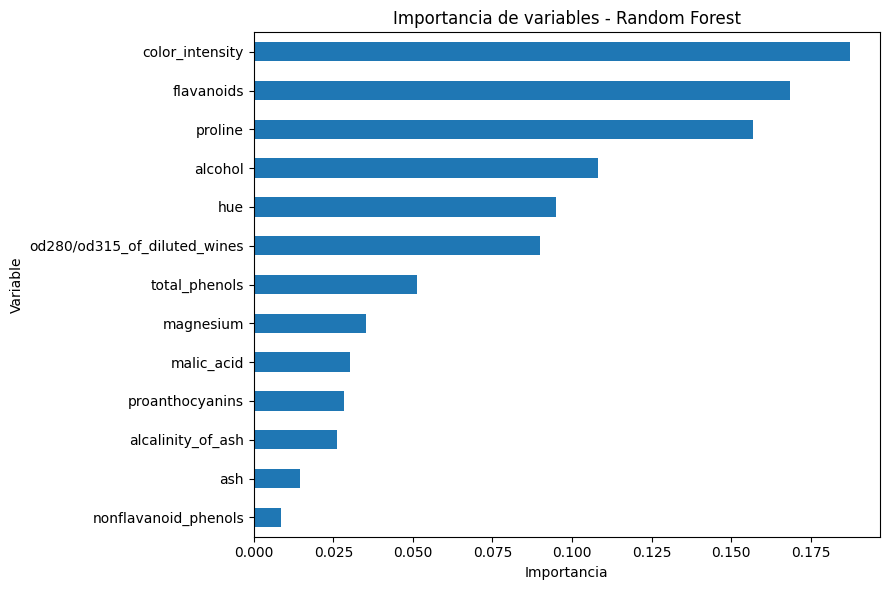

In [38]:
# Mostramos gráficamente las variables más importantes
importancias.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 3. Support Vector Machine (SVM)

SVM busca una frontera que separe las clases dejando el mayor margen posible. En este modelo es importante utilizar datos escalados.

In [39]:
# Creamos el modelo SVM utilizando el kernel RBF
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

In [40]:
# Entrenamos el modelo SVM con los datos escalados
inicio = time.perf_counter()
svm.fit(X_train_escalado, y_train)
tiempo_svm = time.perf_counter() - inicio

In [41]:
# Realizamos predicciones con SVM
pred_svm = svm.predict(X_test_escalado)

In [42]:
# Calculamos la exactitud de SVM
accuracy_svm = accuracy_score(y_test, pred_svm)

print(f"Accuracy de SVM: {accuracy_svm:.4f}")
print(f"Porcentaje de aciertos: {accuracy_svm * 100:.2f}%")
print(f"Tiempo de entrenamiento: {tiempo_svm:.6f} segundos")

Accuracy de SVM: 0.9722
Porcentaje de aciertos: 97.22%
Tiempo de entrenamiento: 0.002576 segundos


In [43]:
# Mostramos el reporte de clasificación de SVM
print(classification_report(
    y_test,
    pred_svm,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



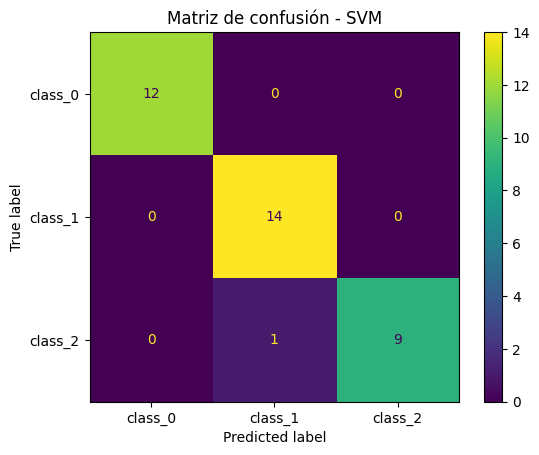

In [44]:
# Mostramos la matriz de confusión de SVM
cm_svm = confusion_matrix(y_test, pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=nombres_clases
)

disp.plot()
plt.title("Matriz de confusión - SVM")
plt.show()

# 4. Regresión Lineal

La Regresión Lineal está diseñada principalmente para predecir valores numéricos continuos y no para problemas de clasificación.

Para incluirla en la comparación, se entrenará con las clases numéricas `0`, `1` y `2`. Después, sus resultados se redondearán y limitarán al rango de clases existentes. Este procedimiento sirve únicamente como referencia académica; para clasificación normalmente se recomienda utilizar Regresión Logística.

In [45]:
# Creamos el modelo de Regresión Lineal
regresion_lineal = LinearRegression()

In [46]:
# Entrenamos la Regresión Lineal utilizando los datos escalados
inicio = time.perf_counter()
regresion_lineal.fit(X_train_escalado, y_train)
tiempo_regresion_lineal = time.perf_counter() - inicio

In [47]:
# La Regresión Lineal produce valores continuos
pred_lineal_continua = regresion_lineal.predict(X_test_escalado)

print("Primeras predicciones continuas:")
print(pred_lineal_continua[:10])

Primeras predicciones continuas:
[-0.2842064   1.78898975  0.05887021 -0.1582246   0.84081696 -0.14959093
 -0.13091123  0.48441561  1.20220867  2.06838029]


In [48]:
# Redondeamos las predicciones y las limitamos a las clases 0, 1 y 2
pred_lineal = np.rint(pred_lineal_continua).astype(int)
pred_lineal = np.clip(pred_lineal, y.min(), y.max())

print("Primeras predicciones convertidas en clases:")
print(pred_lineal[:10])

Primeras predicciones convertidas en clases:
[0 2 0 0 1 0 0 0 1 2]


In [49]:
# Calculamos la exactitud de la Regresión Lineal convertida en clasificador
accuracy_regresion_lineal = accuracy_score(y_test, pred_lineal)

print(f"Accuracy de Regresión Lineal: {accuracy_regresion_lineal:.4f}")
print(f"Porcentaje de aciertos: {accuracy_regresion_lineal * 100:.2f}%")
print(f"Tiempo de entrenamiento: {tiempo_regresion_lineal:.6f} segundos")

Accuracy de Regresión Lineal: 0.8889
Porcentaje de aciertos: 88.89%
Tiempo de entrenamiento: 0.002919 segundos


In [50]:
# Mostramos el reporte de clasificación de la Regresión Lineal
print(classification_report(
    y_test,
    pred_lineal,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

     class_0       0.80      1.00      0.89        12
     class_1       0.92      0.79      0.85        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.89        36
   macro avg       0.91      0.90      0.89        36
weighted avg       0.90      0.89      0.89        36



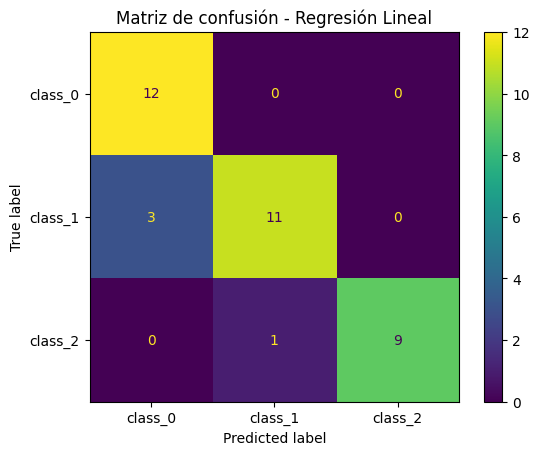

In [51]:
# Mostramos la matriz de confusión de la Regresión Lineal
cm_regresion_lineal = confusion_matrix(y_test, pred_lineal)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_regresion_lineal,
    display_labels=nombres_clases
)

disp.plot()
plt.title("Matriz de confusión - Regresión Lineal")
plt.show()

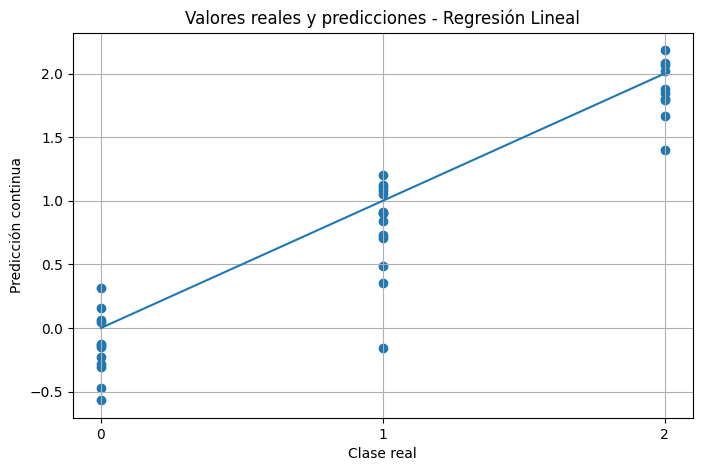

In [52]:
# Comparamos los valores reales con las predicciones continuas
plt.figure(figsize=(8, 5))
plt.scatter(y_test, pred_lineal_continua)
plt.plot([0, 2], [0, 2])
plt.title("Valores reales y predicciones - Regresión Lineal")
plt.xlabel("Clase real")
plt.ylabel("Predicción continua")
plt.xticks([0, 1, 2])
plt.grid(True)
plt.show()

## Comparación general de los algoritmos

In [53]:
# Creamos una tabla con los resultados obtenidos
resultados = pd.DataFrame({
    "Algoritmo": [
        "Árbol de Decisión",
        "Random Forest",
        "SVM",
        "Regresión Lineal"
    ],
    "Accuracy": [
        accuracy_arbol,
        accuracy_random_forest,
        accuracy_svm,
        accuracy_regresion_lineal
    ],
    "Porcentaje de aciertos": [
        accuracy_arbol * 100,
        accuracy_random_forest * 100,
        accuracy_svm * 100,
        accuracy_regresion_lineal * 100
    ],
    "Tiempo de entrenamiento (segundos)": [
        tiempo_arbol,
        tiempo_random_forest,
        tiempo_svm,
        tiempo_regresion_lineal
    ]
})

resultados = resultados.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

resultados

,Algoritmo,Accuracy,Porcentaje de aciertos,Tiempo de entrenamiento (segundos)
0,Random Forest,1.000000,100.000000,0.381821
1,SVM,0.972222,97.222222,0.002576
2,Árbol de Decisión,0.944444,94.444444,0.006153
3,Regresión Lineal,0.888889,88.888889,0.002919


In [54]:
# Identificamos automáticamente el modelo con mayor exactitud
mejor_modelo = resultados.iloc[0]

print("Mejor algoritmo:", mejor_modelo["Algoritmo"])
print(f"Accuracy: {mejor_modelo['Accuracy']:.4f}")
print(f"Porcentaje de aciertos: {mejor_modelo['Porcentaje de aciertos']:.2f}%")

Mejor algoritmo: Random Forest
Accuracy: 1.0000
Porcentaje de aciertos: 100.00%


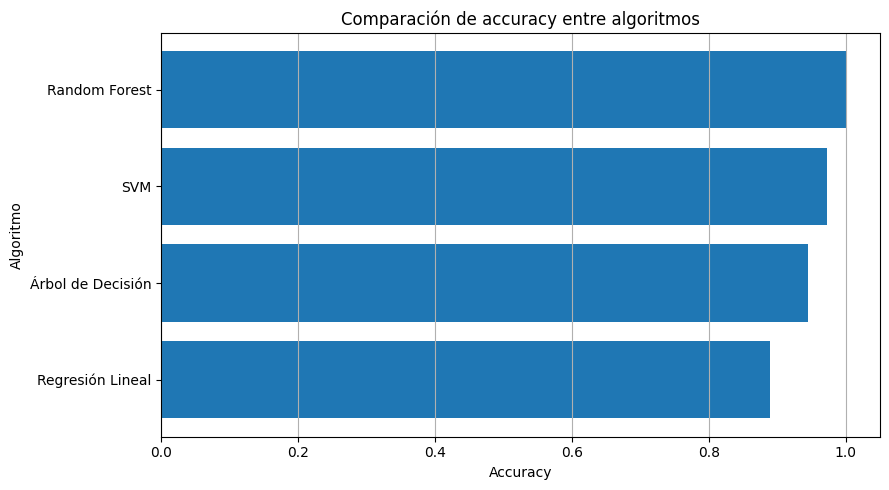

In [55]:
# Graficamos la exactitud de cada algoritmo
resultados_ordenados = resultados.sort_values(by="Accuracy")

plt.figure(figsize=(9, 5))
plt.barh(
    resultados_ordenados["Algoritmo"],
    resultados_ordenados["Accuracy"]
)
plt.title("Comparación de accuracy entre algoritmos")
plt.xlabel("Accuracy")
plt.ylabel("Algoritmo")
plt.xlim(0, 1.05)
plt.grid(axis="x")
plt.tight_layout()
plt.show()

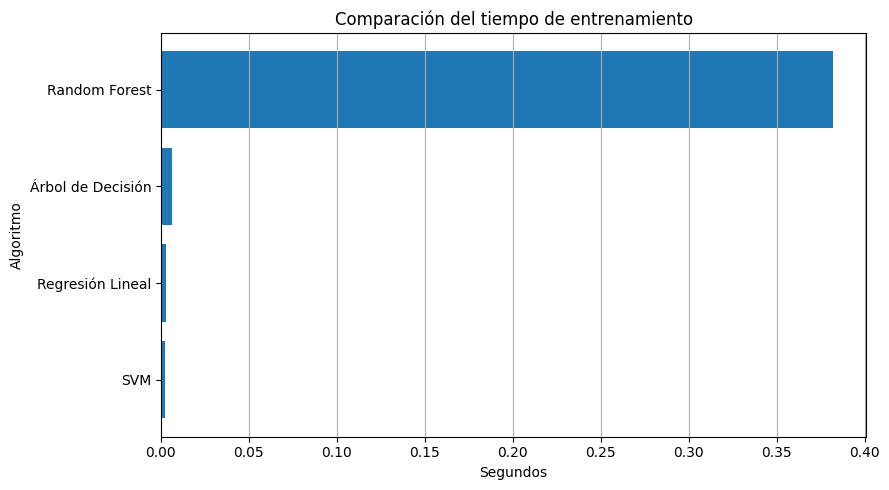

In [56]:
# Graficamos el tiempo de entrenamiento de cada algoritmo
resultados_tiempo = resultados.sort_values(
    by="Tiempo de entrenamiento (segundos)"
)

plt.figure(figsize=(9, 5))
plt.barh(
    resultados_tiempo["Algoritmo"],
    resultados_tiempo["Tiempo de entrenamiento (segundos)"]
)
plt.title("Comparación del tiempo de entrenamiento")
plt.xlabel("Segundos")
plt.ylabel("Algoritmo")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [57]:
# Mostramos una comparación directa entre valores reales y predicciones
comparacion = pd.DataFrame({
    "Valor real": y_test.values,
    "Árbol de Decisión": pred_arbol,
    "Random Forest": pred_random_forest,
    "SVM": pred_svm,
    "Regresión Lineal": pred_lineal
})

comparacion.head(20)

,Valor real,Árbol de Decisión,Random Forest,SVM,Regresión Lineal
0,0,0,0,0,0
1,2,1,2,2,2
2,0,0,0,0,0
3,1,1,1,1,0
4,1,1,1,1,1
5,0,0,0,0,0
6,0,0,0,0,0
7,1,1,1,1,0
8,1,1,1,1,1
9,2,2,2,2,2


## Interpretación de los resultados

La exactitud muestra el porcentaje total de predicciones correctas, pero no debe ser la única métrica analizada. La matriz de confusión permite observar en qué clases se presentaron los errores, mientras que el reporte de clasificación muestra la precisión, el recall y el F1-score de cada clase.

También debe considerarse el tiempo de entrenamiento, la facilidad de interpretación y el tipo de problema. Un Árbol de Decisión es fácil de explicar, Random Forest suele ofrecer resultados sólidos, SVM funciona bien con datos escalados y la Regresión Lineal no es la opción adecuada para clasificar categorías.

## Conclusiones

En este laboratorio se evaluaron cuatro algoritmos utilizando el mismo conjunto de entrenamiento y prueba del dataset Wine. Antes de entrenar los modelos se verificaron valores nulos y registros duplicados. También se estandarizaron las variables utilizadas por SVM y Regresión Lineal, ya que estos algoritmos son sensibles a las diferencias de escala.

Con la configuración utilizada, Random Forest obtuvo el mejor desempeño y clasificó correctamente todos los registros del conjunto de prueba. SVM también alcanzó una exactitud alta, mientras que el Árbol de Decisión presentó un buen resultado y tuvo la ventaja de ser fácil de interpretar mediante su estructura gráfica.

La Regresión Lineal obtuvo el rendimiento más bajo. Esto era esperado porque fue creada para predecir cantidades continuas y no categorías. Para poder evaluarla fue necesario redondear sus resultados, lo cual puede generar clasificaciones incorrectas.

De acuerdo con los resultados obtenidos, Random Forest sería la primera opción para integrar en un sistema que necesite clasificar los tipos de vino. Sin embargo, antes de tomar una decisión definitiva sería conveniente realizar validación cruzada y probar diferentes hiperparámetros para comprobar que el desempeño se mantiene con otros conjuntos de datos.